Why is it called polynomial linear regression -> because the relation between Y hat and the coefficients is linear

if the error is too high when you apply linear regression on non-linear data, then apply polynomial features.

Polynomial features can be applied only on the input columns and in the data preprocessing stage.

# 2D Polynomial Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

degree :
1. very high -> tries to touch every training point -> overfitting.
works exceptionally well on training data, but not on test data.
2. very low -> doesn't capture the true relationship --> underfitting. doesn't extract the pattern of both train as well as test data.

non linear data.

y = 0.8x^2 + 0.9x + 2


In [2]:
np.random.rand(2,2)

array([[0.2227522 , 0.53403027],
       [0.55224195, 0.216375  ]])

*added random noise to move the points up and down*

In [3]:
# 200 training points in the range of 0 to 1
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2
y = y + np.random.randn(200,1)

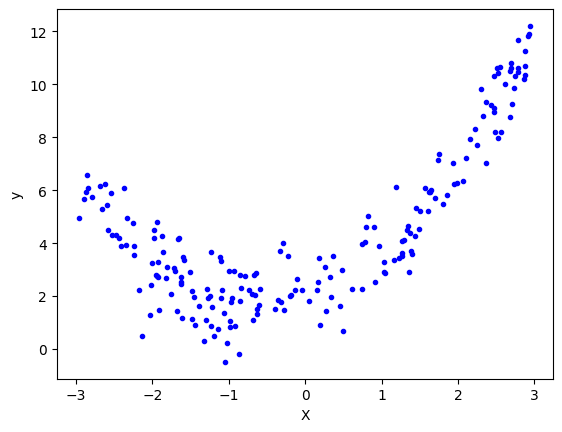

In [4]:
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

*train test split*

In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=2
)

*Applying linear regression on non-linear data*

In [6]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [7]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.4624731907011216

*best fit line*

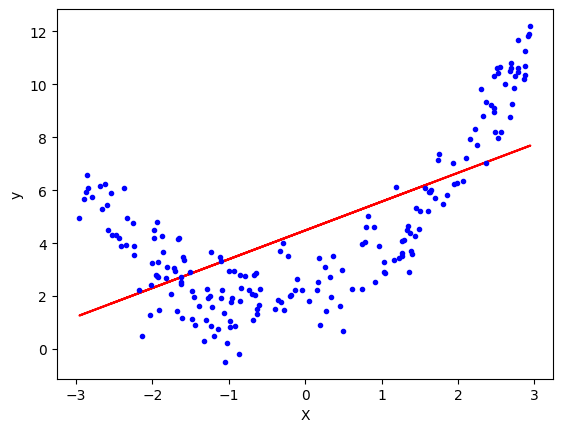

In [8]:
plt.plot(X_train,lr.predict(X_train),color='r') #best fit line
plt.plot(X,y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

*Applying polynomial linear regression of degree 2*

In [9]:
poly = PolynomialFeatures(
    degree=2,include_bias=True
)
# if we make include_bias = False,
# then the intercept term will not be included

In [10]:
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

*After fitting it gets to know that it is a parabola of degree 2, so the combo of degrees of x and y combined should be lesser than or equal to 2*

*If degree=2, and input column=1, then we get three columns X^0,X^1,X^2*

*For every input column we get 3 columns* (in case of degree=2)

In this equation, we have one input(x) and one output column(y) -> y = 0.8x^2 + 0.9x + 2

In [11]:
print(X_train[0])
# X_train^0, X_train^1, X_train^2
print(X_train_trans[0])

[-2.53688842]
[ 1.         -2.53688842  6.43580286]


In [12]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.8774937851324566

In [14]:
y_pred.min()

np.float64(1.8179873753697238)

In [15]:
y_pred.max()

np.float64(10.984838785527412)

*beta0, beta1, beta2*

In [16]:
print(lr.coef_)

[[0.         0.91662312 0.77008102]]


*if you dont want the coeff for the bias term, set include_bias=False, since it is already handled by intercept_*

In [17]:
print(lr.intercept_)

[2.047499]


we got the coefficients almost equal to original ->

y = 0.8x^2 + 0.9x + 2

In [18]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

In [19]:
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

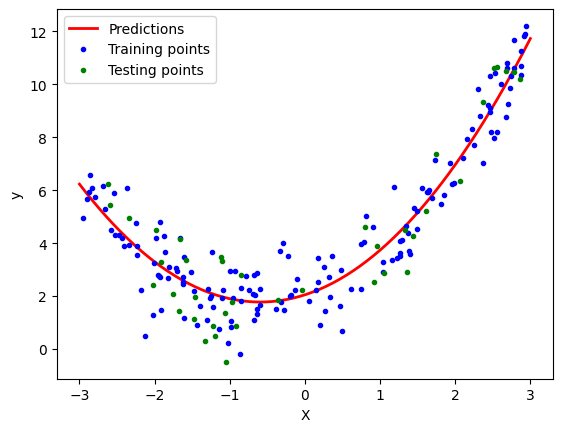

In [20]:
plt.plot(X_new,y_new,"r-",linewidth=2,label="Predictions")
plt.plot(X_train,y_train,"b.", label="Training points")
plt.plot(X_test, y_test,"g.", label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

*non-linear relationship successfully extracted*

In [21]:
def polynomial_regression(degree):

  # extract polynomial features from the input cols
  poly_features = PolynomialFeatures(
      degree=degree,
      include_bias=False
  )
  # Apply standardisation to scale the values when
  # degrees are super high before passing to the linear regr model
  # X^0, X^1, X^2, ...X^240, X^249 (degree=249)
  std_scaler = StandardScaler()
  # since we applied polynomial features on non-linear data
  # we can do normal linear regression
  lin_reg = LinearRegression()
  polynomial_regression = Pipeline([
      ("poly_features",poly_features),
      ("std_scaler",std_scaler),
      ("lin_reg",lin_reg)
  ])
  polynomial_regression.fit(X,y)
  # 100 new points
  X_new = np.linspace(-3,3,100).reshape(100,1)
  y_new = polynomial_regression.predict(X_new)
  plt.plot(
      X_new,y_new,"r",label="Degree" + str(degree),
      linewidth=2
  )
  plt.plot(X_train,y_train,"b.",linewidth=3)
  plt.plot(X_test,y_test,"g.",linewidth=3)
  plt.legend(loc="upper left")
  plt.xlabel("X")
  plt.ylabel("y")
  # xmin, xmax, ymin, ymax
  plt.axis([-3,3,0,10])
  plt.show()
  return polynomial_regression


in Pipeline:
polynomial_regression.fit(X,y)

1. poly_features.fit_transform(X)
2. std_scaler.fit_transform(X_poly_features_trf)
3. lin_reg.fit(X_scaled,y)


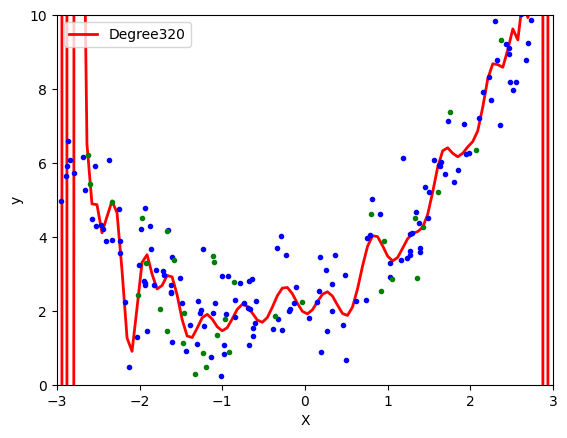

Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=320, include_bias=False)),
                ('std_scaler', StandardScaler()),
                ('lin_reg', LinearRegression())])

In [22]:
polynomial_regression(320)

higher degree -> tries to touch every training point -> leads to overfitting

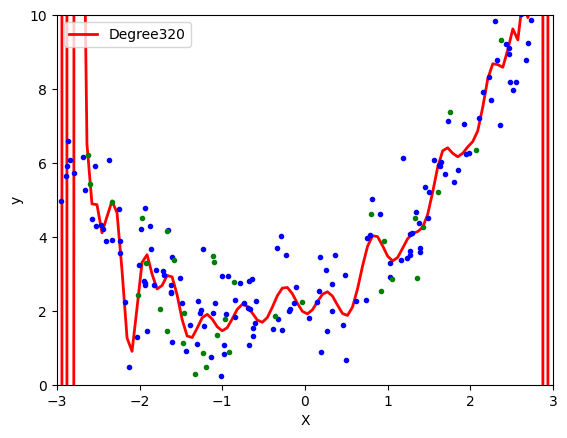

array([[  1],
       [  2],
       [  3],
       [  4],
       [  5],
       [  6],
       [  7],
       [  8],
       [  9],
       [ 10],
       [ 11],
       [ 12],
       [ 13],
       [ 14],
       [ 15],
       [ 16],
       [ 17],
       [ 18],
       [ 19],
       [ 20],
       [ 21],
       [ 22],
       [ 23],
       [ 24],
       [ 25],
       [ 26],
       [ 27],
       [ 28],
       [ 29],
       [ 30],
       [ 31],
       [ 32],
       [ 33],
       [ 34],
       [ 35],
       [ 36],
       [ 37],
       [ 38],
       [ 39],
       [ 40],
       [ 41],
       [ 42],
       [ 43],
       [ 44],
       [ 45],
       [ 46],
       [ 47],
       [ 48],
       [ 49],
       [ 50],
       [ 51],
       [ 52],
       [ 53],
       [ 54],
       [ 55],
       [ 56],
       [ 57],
       [ 58],
       [ 59],
       [ 60],
       [ 61],
       [ 62],
       [ 63],
       [ 64],
       [ 65],
       [ 66],
       [ 67],
       [ 68],
       [ 69],
       [ 70],
       [ 71],
      

In [23]:
pipe = polynomial_regression(320)
pipe[0].powers_ # here intercept is not included

In [24]:
poly.powers_ #polynomial of degree 2

array([[0],
       [1],
       [2]])

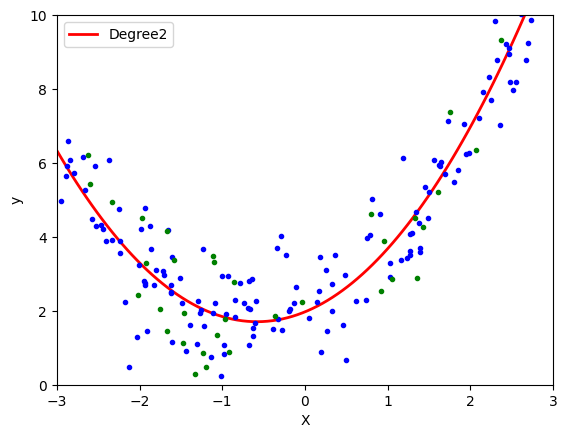

Pipeline(steps=[('poly_features', PolynomialFeatures(include_bias=False)),
                ('std_scaler', StandardScaler()),
                ('lin_reg', LinearRegression())])

In [25]:
polynomial_regression(2)

In [26]:
pipe[2].coef_.shape

(1, 320)

when we fit the pipe with X,y->
we are basically finding out the no.of coefficients (equal to the degree)

and then using these coefficients we predict the y values, for the new points of x.

the data is same, i.e X and y, its just shows how much poly features are being extracted.

and the rest is train and test data

if degree is too high -> then too many poly features and the overfitting happens

if degree is too low -> then less poly features and underfitting happens

*Applying Gradient Descent*

In [28]:
poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


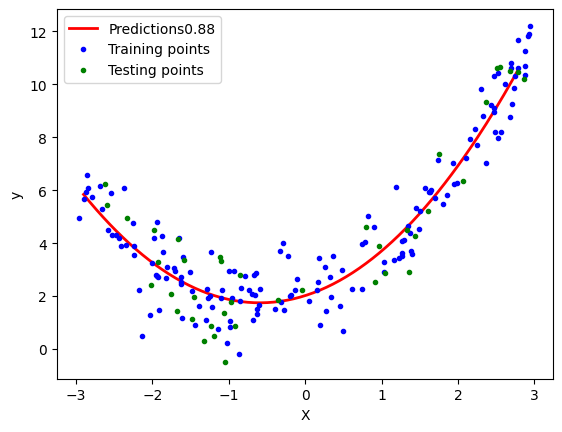

In [30]:
sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)
# 200 new points
X_new = np.linspace(-2.9,2.8,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

plt.plot(X_new,y_new,"r-",linewidth=2,label="Predictions" + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train,y_train,"b.", label="Training points")
plt.plot(X_test,y_test,"g.", label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# 3D Polynomial Regression

*here we have 2 input columns*

z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [31]:
x = 7 * np.random.rand(100,1) - 2.8
y = 7 * np.random.rand(100,1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100,1)

In [35]:
import plotly.express as px

fig = px.scatter_3d(
                    x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.show()

In [36]:
lr = LinearRegression()
# input -> x,y
# output -> z
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input, y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T
z_final = lr.predict(final).reshape(10,10)

In [39]:
import plotly.graph_objects as go
fig = px.scatter_3d(x=x.ravel(),y=y.ravel(),z=z.ravel())
fig.add_trace(
    go.Surface(x = x_input, y=y_input, z=z_final)
)
fig.show()

In [40]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

combined power of x,y should be less than or equal to 30 -> (degree=30)

In [41]:
poly = PolynomialFeatures(degree=30)
X_multi_trans = poly.fit_transform(X_multi)

In [45]:
print("Input",poly.n_features_in_)
print("Output",poly.n_output_features_)
print("Powers\n",poly.powers_)

Input 2
Output 496
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 [ 2  0]
 [ 1  1]
 [ 0  2]
 [ 3  0]
 [ 2  1]
 [ 1  2]
 [ 0  3]
 [ 4  0]
 [ 3  1]
 [ 2  2]
 [ 1  3]
 [ 0  4]
 [ 5  0]
 [ 4  1]
 [ 3  2]
 [ 2  3]
 [ 1  4]
 [ 0  5]
 [ 6  0]
 [ 5  1]
 [ 4  2]
 [ 3  3]
 [ 2  4]
 [ 1  5]
 [ 0  6]
 [ 7  0]
 [ 6  1]
 [ 5  2]
 [ 4  3]
 [ 3  4]
 [ 2  5]
 [ 1  6]
 [ 0  7]
 [ 8  0]
 [ 7  1]
 [ 6  2]
 [ 5  3]
 [ 4  4]
 [ 3  5]
 [ 2  6]
 [ 1  7]
 [ 0  8]
 [ 9  0]
 [ 8  1]
 [ 7  2]
 [ 6  3]
 [ 5  4]
 [ 4  5]
 [ 3  6]
 [ 2  7]
 [ 1  8]
 [ 0  9]
 [10  0]
 [ 9  1]
 [ 8  2]
 [ 7  3]
 [ 6  4]
 [ 5  5]
 [ 4  6]
 [ 3  7]
 [ 2  8]
 [ 1  9]
 [ 0 10]
 [11  0]
 [10  1]
 [ 9  2]
 [ 8  3]
 [ 7  4]
 [ 6  5]
 [ 5  6]
 [ 4  7]
 [ 3  8]
 [ 2  9]
 [ 1 10]
 [ 0 11]
 [12  0]
 [11  1]
 [10  2]
 [ 9  3]
 [ 8  4]
 [ 7  5]
 [ 6  6]
 [ 5  7]
 [ 4  8]
 [ 3  9]
 [ 2 10]
 [ 1 11]
 [ 0 12]
 [13  0]
 [12  1]
 [11  2]
 [10  3]
 [ 9  4]
 [ 8  5]
 [ 7  6]
 [ 6  7]
 [ 5  8]
 [ 4  9]
 [ 3 10]
 [ 2 11]
 [ 1 12]
 [ 0 13]
 [14  0]
 [13  1]
 [12  2]
 

In [46]:
poly.powers_.shape

(496, 2)

In [47]:
X_multi_trans.shape

(100, 496)

In [48]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [51]:
# 496 o/p features
X_test_multi = poly.transform(final)
z_final = lr.predict(X_multi_trans).reshape(10,10)

In [52]:
fig = px.scatter_3d(
    x=x.ravel(),y=y.ravel(),z=z.ravel()
)
# for 2D plane
fig.add_trace(
    go.Surface(x=x_input, y=y_input, z=z_final)
)
fig.update_layout(scene=dict(
    zaxis=dict(range=[0,35])
))
fig.show()

tries to touch every training point, overfitting